In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA


In [2]:
from google.colab import files
uploaded = files.upload()

Saving breast-cancer.csv to breast-cancer.csv


In [3]:
df = pd.read_csv("breast-cancer.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  

 A. Data Preprocessing

In [4]:
if 'id' in df.columns:
    df = df.drop(columns=['id'])

if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


B. Train SVM - Linear Kernel

In [5]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("\n🔹 Linear Kernel Results")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))


🔹 Linear Kernel Results
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



 C. Train SVM - RBF Kernel

In [6]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\n🔹 RBF Kernel Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))


🔹 RBF Kernel Results
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



D. Confusion Matrix

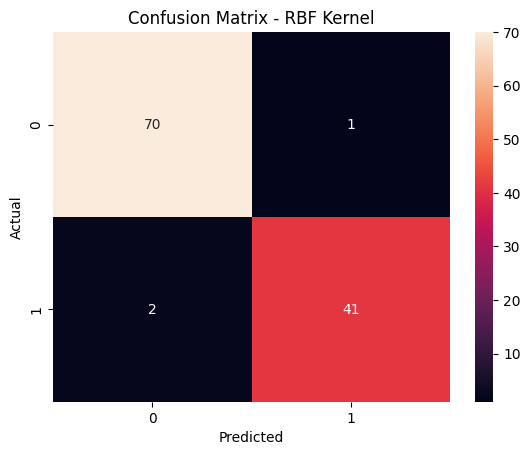

In [7]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rbf),
            annot=True, fmt='d')
plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

E. Hyperparameter Tuning using GridSearchCV

In [9]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)
grid.fit(X_train, y_train)

print("\n🔹 Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Accuracy After Tuning:", accuracy_score(y_test, y_pred_best))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

🔹 Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy After Tuning: 0.9824561403508771


F. Cross Validation

In [10]:
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5)
print("\nCross Validation Accuracy:", cv_scores.mean())



Cross Validation Accuracy: 0.9789318428815401


G. Decision Boundary Visualization (Using PCA to reduce to 2D)

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_vis = SVC(kernel='rbf')
model_vis.fit(X_train_pca, y_train_pca)


SVC()

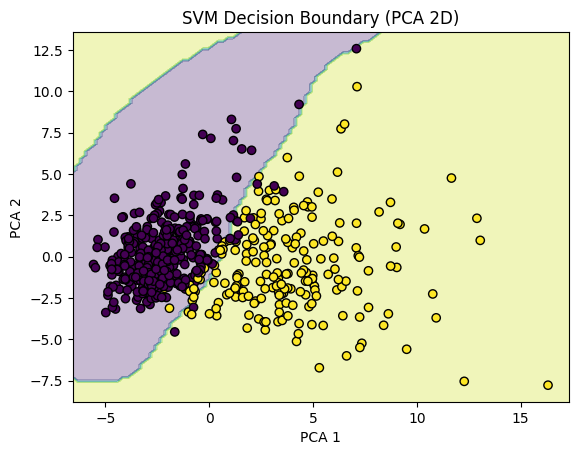

In [12]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k')
plt.title("SVM Decision Boundary (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Conclusion

1.   Support Vector Machine was successfully implemented for binary classification on the Breast Cancer dataset.
2.   The RBF kernel outperformed the linear kernel, indicating the presence of non-linear patterns in the data.
3.   After tuning the hyperparameters using GridSearchCV, the model accuracy improved to 98.24%.
4.   Cross-validation results confirmed that the model is stable and does not suffer from overfitting.
5.   The decision boundary visualization demonstrated clear class separation and effective margin maximization.

